In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [14]:
import pandas as pd

df = pd.read_csv(
    "/content/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2015_20260309.csv",
    nrows=50000
)

df.head()

/tmp/ipykernel_3051/996732841.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,Health Service Area,Hospital County,Operating Certificate Number,Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Abortion Edit Indicator,Emergency Department Indicator,Total Charges,Total Costs
0,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Private Health Insurance,NaN,0,N,Y,"$5,333.90","$4,818.42"
1,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,NaN,NaN,0,N,Y,"$4,865.99","$4,588.78"
2,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Private Health Insurance,NaN,0,N,Y,"$5,901.54","$5,559.56"
3,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,50 to 69,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,NaN,NaN,0,N,Y,"$3,619.08","$3,567.25"
4,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,M,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,Blue Cross/Blue Shield,Private Health Insurance,0,N,Y,"$3,185.87","$3,167.89"


In [15]:
df.shape

(50000, 34)

In [16]:
df.columns

Index(['Health Service Area', 'Hospital County',
       'Operating Certificate Number', 'Facility Id', 'Facility Name',
       'Age Group', 'Zip Code - 3 digits', 'Gender', 'Race', 'Ethnicity',
       'Length of Stay', 'Type of Admission', 'Patient Disposition',
       'Discharge Year', 'CCS Diagnosis Code', 'CCS Diagnosis Description',
       'CCS Procedure Code', 'CCS Procedure Description', 'APR DRG Code',
       'APR DRG Description', 'APR MDC Code', 'APR MDC Description',
       'APR Severity of Illness Code', 'APR Severity of Illness Description',
       'APR Risk of Mortality', 'APR Medical Surgical Description',
       'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3',
       'Birth Weight', 'Abortion Edit Indicator',
       'Emergency Department Indicator', 'Total Charges', 'Total Costs'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Health Service Area                  49878 non-null  object 
 1   Hospital County                      49878 non-null  object 
 2   Operating Certificate Number         49878 non-null  float64
 3   Facility Id                          49878 non-null  float64
 4   Facility Name                        50000 non-null  object 
 5   Age Group                            50000 non-null  object 
 6   Zip Code - 3 digits                  49463 non-null  object 
 7   Gender                               50000 non-null  object 
 8   Race                                 50000 non-null  object 
 9   Ethnicity                            50000 non-null  object 
 10  Length of Stay                       50000 non-null  object 
 11  Type of Admission           

In [18]:
#Check Summary Statistics
df[["Length of Stay","Total Charges","Total Costs"]].describe()

,Length of Stay,Total Charges,Total Costs
count,50000,50000,50000
unique,142,48472,48289
top,2,"$10,548.48","$6,530.37"
freq,11312,47,47


In [21]:
df["Total Charges"].describe()

,Total Charges
count,50000
unique,48472
top,"$10,548.48"
freq,47


In [22]:
df["Total Charges"] = df["Total Charges"].replace('[\$,]', '', regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3051/1258316065.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["Total Charges"] = df["Total Charges"].replace('[\$,]', '', regex=True)


In [24]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"])

In [25]:
df["Total Charges"].describe()

,Total Charges
count,5.000000e+04
mean,2.821496e+04
std,5.877821e+04
min,3.800000e+02
25%,7.037870e+03
50%,1.400444e+04
75%,3.057858e+04
max,3.360488e+06


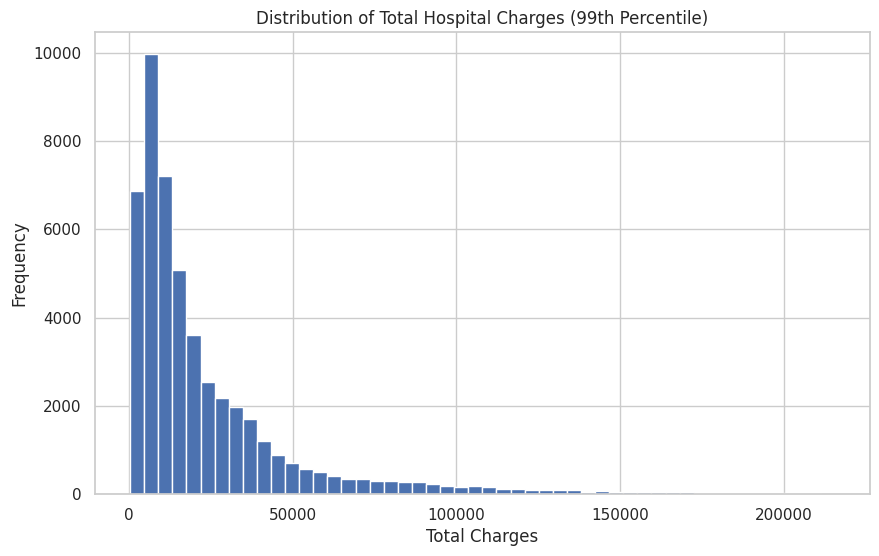

In [27]:
#Histogram of total charges
upper = df["Total Charges"].quantile(0.99)

plt.hist(df[df["Total Charges"] <= upper]["Total Charges"], bins=50)

plt.title("Distribution of Total Hospital Charges (99th Percentile)")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

In [28]:
df["Total Costs"] = df["Total Costs"].replace('[\$,]', '', regex=True)
df["Total Costs"] = pd.to_numeric(df["Total Costs"])

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3051/3748999018.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["Total Costs"] = df["Total Costs"].replace('[\$,]', '', regex=True)


In [29]:
df["Total Costs"].describe()

,Total Costs
count,5.000000e+04
mean,1.277513e+04
std,2.341105e+04
min,2.116700e+02
25%,3.664495e+03
50%,6.991435e+03
75%,1.375317e+04
max,1.547036e+06


In [31]:
df["Length of Stay"].unique()[:20]

array(['4', '2', '3', '5', '6', '12', '10', '8', '1', '9', '7', '11',
       '14', '15', '26', '22', '21', '18', '19', '31'], dtype=object)

In [33]:
df["Length of Stay"] = df["Length of Stay"].str.replace(" +", "", regex=False)
df["Length of Stay"] = pd.to_numeric(df["Length of Stay"])

In [34]:
df["Length of Stay"].describe()
df["Length of Stay"].isnull().sum()

np.int64(848)

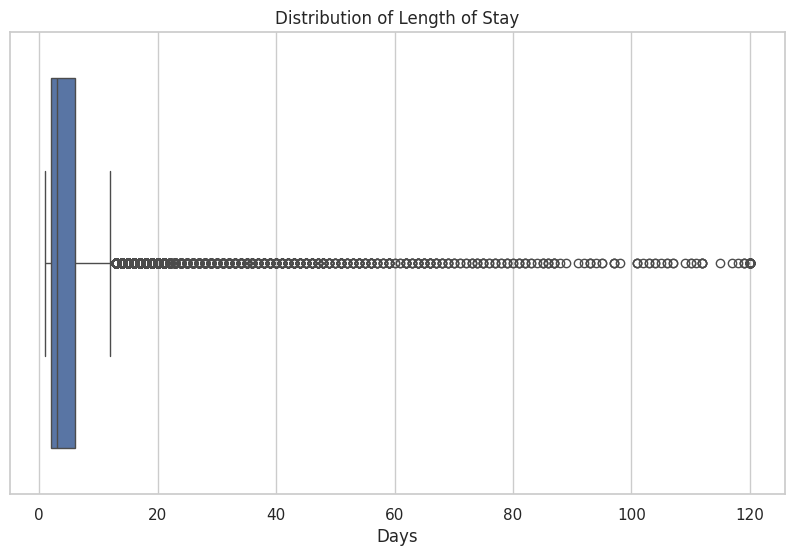

In [35]:
sns.boxplot(x=df["Length of Stay"])

plt.title("Distribution of Length of Stay")
plt.xlabel("Days")

plt.show()

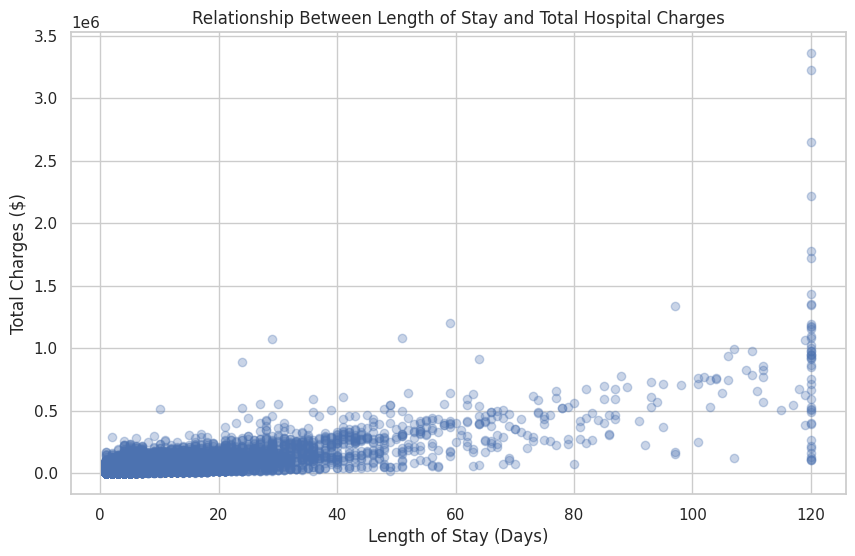

In [36]:
plt.scatter(df["Length of Stay"], df["Total Charges"], alpha=0.3)

plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Charges ($)")
plt.title("Relationship Between Length of Stay and Total Hospital Charges")

plt.show()

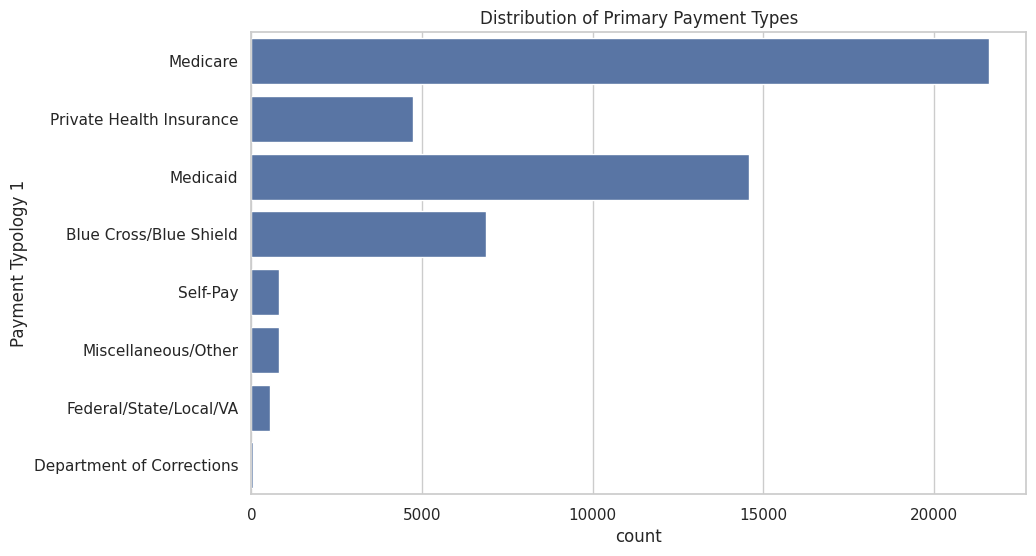

In [37]:
sns.countplot(y="Payment Typology 1", data=df)

plt.title("Distribution of Primary Payment Types")

plt.show()

In [38]:
df.isnull().sum()

,0
Health Service Area,122
Hospital County,122
Operating Certificate Number,122
Facility Id,122
Facility Name,0
Age Group,0
Zip Code - 3 digits,537
Gender,0
Race,0
Ethnicity,0


In [39]:
df.duplicated().sum()

np.int64(29)

In [40]:
df = df.drop_duplicates()

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.shape

(49971, 34)

In [43]:
#Check Summary Statistics
df[["Length of Stay","Total Charges","Total Costs"]].describe()

,Length of Stay,Total Charges,Total Costs
count,49123.000000,4.997100e+04,4.997100e+04
mean,5.175132,2.822935e+04,1.278102e+04
std,7.811199,5.879216e+04,2.341649e+04
min,1.000000,3.800000e+02,2.116700e+02
25%,2.000000,7.046775e+03,3.667790e+03
50%,3.000000,1.401490e+04,6.994100e+03
75%,6.000000,3.059221e+04,1.375706e+04
max,120.000000,3.360488e+06,1.547036e+06
